In [16]:
# Imports
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [17]:
# Fill in your file path here
df = pd.read_csv('')
df = df.drop(columns = ['Unnamed: 0'])
df.columns

FileNotFoundError: [Errno 2] No such file or directory: ''

In [ ]:
# Preview training data
train = df[df['season'] <= 2024]
train

,season,player,age,team,gs,cmp_pct,td_pct,int_pct,one_d,succ_pct,...,gwd,Wins,tot_TD,tot_Yds,cpoe,rtg,aggressiveness,db_epa,TO,MVP
0,2016,Drew Brees,37,NOR,16,70.0,5.5,2.2,265,53.9,...,4,7.0,39,5228,5.523344,101.904858,17.565012,15.201859,19,0
1,2016,Matt Ryan,31,ATL,16,69.9,7.1,1.3,240,52.5,...,2,11.0,38,5061,8.852268,119.783821,21.121527,31.684510,9,1
2,2016,Kirk Cousins,28,WAS,16,67.0,4.1,2.0,227,51.2,...,4,8.0,29,5013,8.643469,98.981961,14.256516,19.124456,15,0
3,2016,Aaron Rodgers,33,GNB,16,65.7,6.6,1.1,226,49.6,...,2,10.0,44,4797,4.065958,105.595821,17.177051,25.738424,11,0
4,2016,Philip Rivers,35,SDG,16,60.4,5.7,3.6,215,46.6,...,1,5.0,33,4421,0.664685,90.022297,18.681552,8.985894,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,2024,Jayden Daniels,24,WAS,17,69.0,5.2,1.9,170,47.1,...,4,12.0,31,4459,1.237116,100.962087,13.903248,19.202904,9,0
184,2024,Caleb Williams,23,CHI,17,62.5,3.6,1.1,171,40.3,...,1,5.0,20,4030,-1.153730,87.760093,11.901279,-3.228115,11,0
185,2024,Kirk Cousins,36,ATL,14,66.9,4.0,3.5,163,46.4,...,3,7.0,18,3508,3.248059,88.726954,19.525487,6.235192,18,0
186,2024,Jordan Love,26,GNB,15,63.1,5.9,2.6,151,48.3,...,2,9.0,26,3472,-0.669931,95.225035,17.106487,17.871430,11,0


In [ ]:
# Get VIF values
X = df[['age', 'gs', 'cmp_pct', 'td_pct', 'int_pct', 'one_d', 'succ_pct', 'y_a', 'ay_a', 
        'y_c', 'y_g', 'qbr', 'sk_pct', 'four_qc', 'gwd', 'Wins', 'tot_TD', 'tot_Yds', 'cpoe',
        'rtg', 'aggressiveness', 'db_epa', 'TO']]

y = df['MVP']

X = sm.add_constant(X)  
X = X.astype(float)

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

           feature           VIF
0            const  42784.106792
1              age      1.696178
2               gs      5.967980
3          cmp_pct    113.659220
4           td_pct    102.096423
5          int_pct    147.106001
6            one_d     21.534601
7         succ_pct      9.610517
8              y_a    500.834474
9             ay_a   1337.464723
10             y_c    231.921459
11             y_g     24.863260
12             qbr      6.101254
13          sk_pct      3.217742
14         four_qc      4.207367
15             gwd      4.461951
16            Wins      2.677498
17          tot_TD     11.378201
18         tot_Yds     20.991013
19            cpoe      3.590035
20             rtg     29.543060
21  aggressiveness      2.216081
22          db_epa     11.890474
23              TO      7.245803


In [ ]:
# Whats better, a model that has a high psuedo R-squared or one thats right?
# Choose up to 5 features
X = train[[]]
y = train['MVP']
X = X.astype(float)

X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.115156
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                    MVP   No. Observations:                  188
Model:                          Logit   Df Residuals:                      182
Method:                           MLE   Df Model:                            5
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.4833
Time:                        14:38:06   Log-Likelihood:                -21.649
converged:                       True   LL-Null:                       -41.896
Covariance Type:            nonrobust   LLR p-value:                 1.188e-07
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -18.7983      7.702     -2.441      0.015     -33.894      -3.703
Wins            

In [ ]:
# Get data we are testing on
test = df[df['season'] == 2025]

test = test[['player', 'age', 'gs', 'cmp_pct', 'td_pct', 'int_pct', 'y_g', 'qbr', 'sk_pct', 'succ_pct', 'four_qc', 'gwd', 
             'Wins', 'tot_TD', 'tot_Yds', 'cpoe', 'rtg', 'aggressiveness', 'db_epa', 'TO']]

               player  MVP_Prob
188  Matthew Stafford  0.552578
191        Drake Maye  0.467668
193   Trevor Lawrence  0.148531
198        Josh Allen  0.093133
195            Bo Nix  0.049917
202       Jalen Hurts  0.029524
192       Sam Darnold  0.023475
194    Caleb Williams  0.013163
189        Jared Goff  0.007881
196    Justin Herbert  0.007313


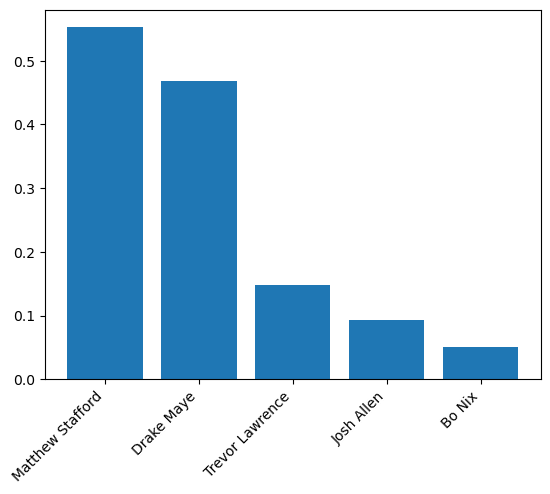

In [ ]:
# Get predictions and make small chart
test = test[['player','aggressiveness','cpoe', 'rtg','age','Wins', 'tot_TD','succ_pct','gwd','qbr','TO','db_epa', 'sk_pct']]
features = [] # Copy the features you chose into here as well

df.columns = df.columns.astype(str)
test.columns = test.columns.astype(str)
train.columns = train.columns.astype(str)

X = train[features]
y = train['MVP']

X_CT = test[features]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

test['MVP_Prob'] = model.predict_proba(X_CT)[:, 1]
top_candidates = test[['player', 'MVP_Prob']].sort_values('MVP_Prob', ascending=False)
print(top_candidates.head(10))

top_candidates = top_candidates.head(5)
plt.bar(top_candidates['player'], top_candidates['MVP_Prob'])
plt.xticks(rotation=45, ha='right')
plt.show()

ROC AUC Score: 0.9481


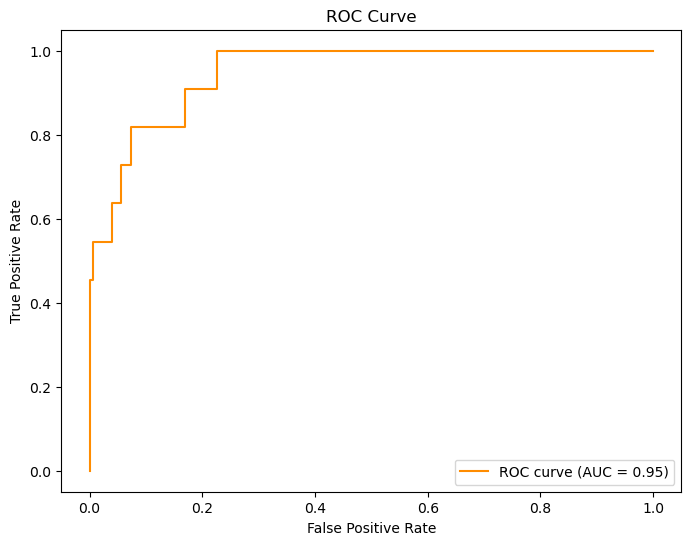

In [ ]:
# Calculate ROC AUC score, and make plot
y_score = model.predict_proba(X)[:, 1] 

auc = roc_auc_score(y, y_score)
print(f"ROC AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# STOP HERE!

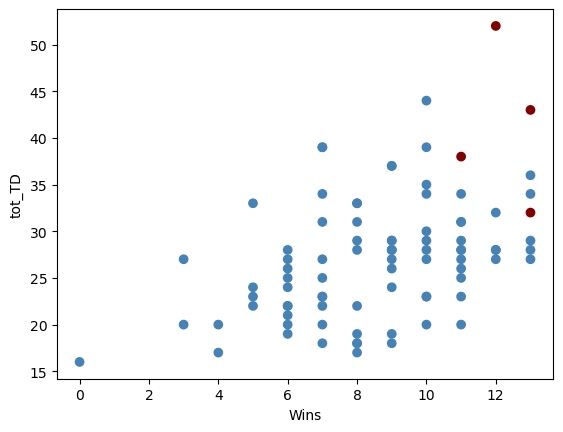

In [ ]:
# Why does it sometimes give us an error when predicting past years?
check = df[df['season'] <= 2019]
colors = check['MVP'].map({1: 'maroon', 0: 'steelblue'})
plt.scatter(check['Wins'], check['tot_TD'], c=colors)
plt.xlabel('Wins')
plt.ylabel('tot_TD')
plt.show()

In [ ]:
# How can we explain why the model gave us a certain result? (need to adjust train timeframe)
df['23lj'] = ((df['season'] == 2023) & (df['player'] == 'Lamar Jackson')).astype(int)

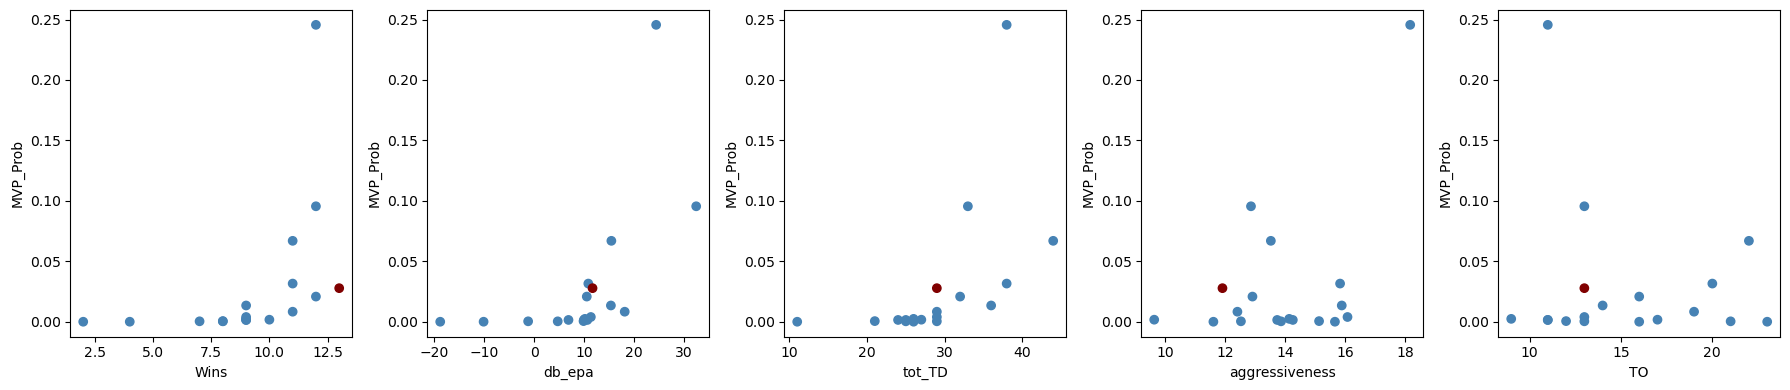

In [ ]:
test_2023 = df[df['season'] == 2023].copy()

X_2023 = test_2023[features]
test_2023['MVP_Prob'] = model.predict_proba(X_2023)[:, 1]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, feat in zip(axes, features):
    colors = test_2023['23lj'].map({1: 'maroon', 0: 'steelblue'})
    ax.scatter(test_2023[feat], test_2023['MVP_Prob'], c=colors)
    ax.set_xlabel(feat)
    ax.set_ylabel('MVP_Prob')

plt.tight_layout()
plt.show()